# The binomial distribution
If $p$ is the probability that an event will happen in any single trial (called the probability of a _success_) and $q=1-p$ is the probability that it will fail to happen in any single trial (called the probability of a _failure_), then the probability that the event will happen exactly $X$ times in$N$ trials (i.e., $X$ successes and $N-X$ failures will occur) is given by

\begin{equation}\tag{1}
p(X) = \binom{N}{X}p^Xq^{N-X}=\frac{N!}{X!(N-X)!}p^Xq^{N-X}
\end{equation}

where $X=0,1,2,\ldots,N$; $N!=N(N-1)(N-2)\cdots1$; and $0!=1$ by definition (see Problem 6.34).

__EXAMPLE 1.__ The probability of getting exactly $2$ heads in $6$ tosses of a fair coin is

\begin{align}
\binom{6}{2}\left(\frac{1}{2}\right)^2\left(\frac{1}{2}\right)^{6-2}
=\frac{6}{2!4!}\left(\frac{1}{2}\right)^6=\frac{15}{64}
\end{align}

using formula (1) with $N=6$,$X=2$, and $p=q=\frac{1}{2}$.

In [1]:
binomial.fn <- function(X, N, p) {
    factorial(N)/(factorial(X) * factorial((N - X))) * p^X * (1-p)^(N - X)
}
binomial.fn(2, 6, .5)
15/64

[1] 0.234375

[1] 0.234375

In [2]:
# density
dbinom(2,6,.5)

[1] 0.234375

__EXAMPLE 2.__ The probability of getting at least 4 heads in 6 tosses of a fair coin is
\begin{align}
\binom{6}{4}\left(\frac{1}{2}\right)^4\left(\frac{1}{2}\right)^{6-4} + 
\binom{6}{5}\left(\frac{1}{2}\right)^5\left(\frac{1}{2}\right)^{6-5} +
\binom{6}{6}\left(\frac{1}{2}\right)^6\left(\frac{1}{2}\right)^{6-6} =
\frac{15}{64}+\frac{6}{64}+\frac{1}{64}=\frac{11}{32}
\end{align}

In [20]:
cat("The probabilities of getting 4 heads, getting 5 heads, and getting 6 heads: ", dbinom(4:6,6,.5))
cat(", is: ", sum(dbinom(4:6,6,.5)))
binomial.fn(4,6,.5) + binomial.fn(5,6,.5) + binomial.fn(6,6,.5)
11/32

The probabilities of getting 4 heads, getting 5 heads, and getting 6 heads:  0.234375 0.09375 0.015625, is:  0.34375

[1] 0.34375

[1] 0.34375

The discrete probability distribution (1) is often called the _binomial distribution_ since for $X = 0, 1, 2, \ldots, N$ it corresponds to successive terms of the _binomial formula_, or _binomial expansion_,

\begin{equation}\tag{2}
(q + p)^N = q^N + \binom{N}{1}q^{N-1}p + \binom{N}{2}q^{N-2}p^2+\ldots+p^N
\end{equation}

where $1, \binom{N}{1}, \binom{N}{2},\ldots$ are called binomial coefficients.

__EXAMPLE 3.__
\begin{align}
(q + p)^4 &= q^4 + \binom{4}{1}q^3p + \binom{4}{2}q^2p^2 + \binom{4}{3}qp^3 + p^4 \\
          &= q^4 + 4q^3p+6q^2p^2+4qp^3+p^4
\end{align}
Some properties of the binomial distribution are listed in Table 7.1
|Table 7.1|Binomial Distribution|
|---|---|
|Mean|$\mu=Np$|
|Variance|$\sigma^2=Npq$|
|Standard deviation|$\sigma = \sqrt{Npq}$|
|Moment coefficient of skewness|$\alpha_3 = \frac{q-p}{\sqrt{Npq}}$|
|Moment coefficient of kurtosis|$\alpha_4 = 3 + \frac{1 - 6pq}{Npq}$|

__EXAMPLE 4.__ In $100$ tosses of a fair coin the mean number of heads is $\mu = Np = (100)(\frac{1}{2}) = 50$; this is the _expected_ number of heads in $100$ tosses of the coin. The standard deviation is $\sigma = \sqrt{Npq} = \sqrt{(100)(\frac{1}{2})(\frac{1}{2})} = 5$.

## R programming

### The dbinom function
In order to calculate the binomial probability function for a set of values $x$, a number of trials $n$ and a probability of success $p$ you can make use of the `dbinom` funciton, which has the following syntax:
```{r}
dbinom syntax

dbinom(x,           # X-axis values (x = 0, 1, 2, ..., n)
       size,        # Number of trials (n >= 0)
       prob,        # The probability of success on each trial
       log = FALSE) # If TRUE, probabilities are given as log
```
For instance, if you want to calculate the binomial probability mass function for $x=1,2,\ldots,10$ and aprobability of success in each trial of $0.2$, you can type:

In [1]:
dbinom(x = 1:10, size = 10, prob = 0.2)

[1] 0.2684354560 0.3019898880 0.2013265920 0.0880803840 0.0264241152
 [6] 0.0055050240 0.0007864320 0.0000737280 0.0000040960 0.0000001024

### Plots of the binomial probability function in R

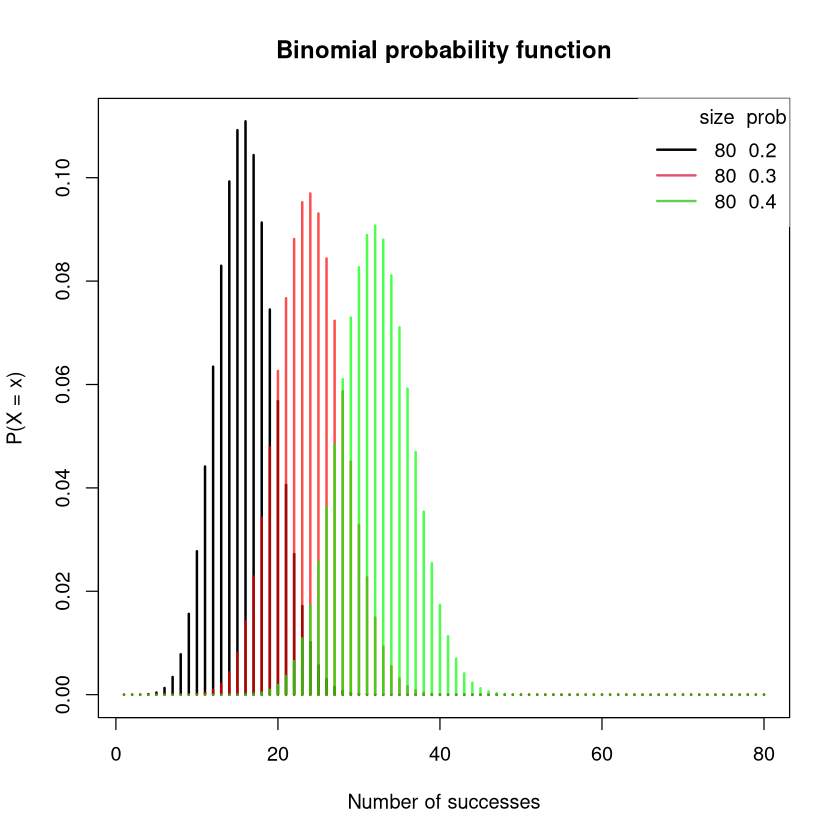

In [2]:
# Grid of X-axis values
x <- 1:80

# size = 80, prob = 0.2
plot(dbinom(x, size = 80, prob = 0.2), type = "h", lwd = 2,
     main = "Binomial probability function",
     ylab = "P(X = x)", xlab = "Number of successes")

# size = 80, prob = 0.3
lines(dbinom(x, size = 80, prob = 0.3), type = "h",
      lwd = 2, col = rgb(1,0,0, 0.7))

# size = 80, prob = 0.4
lines(dbinom(x, size = 80, prob = 0.4), type = "h",
      lwd = 2, col = rgb(0, 1, 0, 0.7))

# Add a legend
legend("topright", legend = c("80  0.2", "80  0.3", "80  0.4"),
       title = "size  prob", title.adj = 0.95,
       lty = 1, col = 1:3, lwd = 2, box.lty = 0)